In [ ]:
!pip install seaborn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage


In [ ]:
df = pd.read_csv("Mall_Customers.csv")
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'Mall_Customers.csv'

In [ ]:
!unzip "archive (1).zip"


Archive:  archive (1).zip
  inflating: Mall_Customers.csv      


In [ ]:
!ls
df = pd.read_csv("Mall_Customers.csv")
df.head()


'archive (1).zip'   Mall_Customers.csv	 sample_data


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df = pd.read_csv("Mall Customers.csv")
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'Mall Customers.csv'

In [ ]:
!ls


'archive (1).zip'   Mall_Customers.csv	 sample_data


In [ ]:
df = pd.read_csv("Mall_Customers.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df = pd.read_csv("Mall_Customers.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.shape


(200, 5)

In [ ]:
df.info()
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


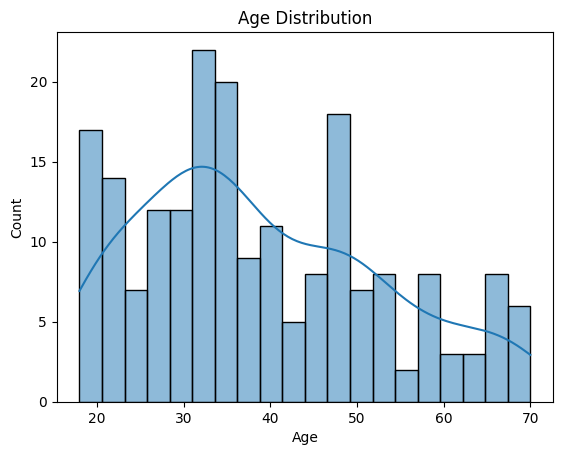

In [ ]:
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()



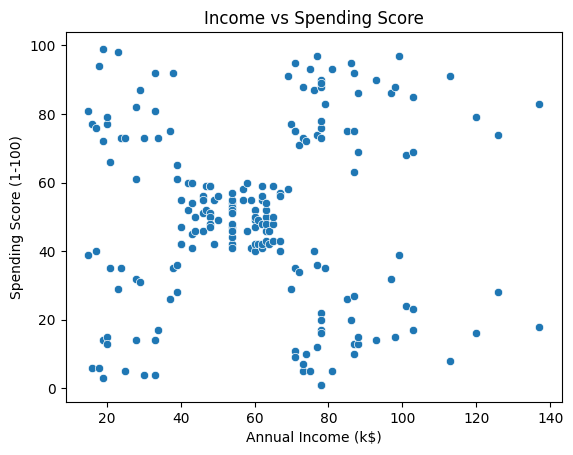

In [ ]:
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)']
)
plt.title("Income vs Spending Score")
plt.show()


In [ ]:
df = df.drop("CustomerID", axis=1)


KeyError: "['CustomerID'] not found in axis"

In [ ]:
df.columns


Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [ ]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [ ]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


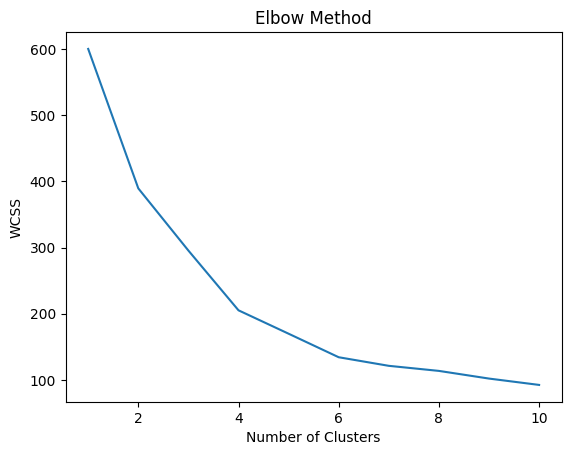

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"For k={k}, Silhouette Score = {score}")


For k=2, Silhouette Score = 0.33547192894004574
For k=3, Silhouette Score = 0.3579234303882264
For k=4, Silhouette Score = 0.4039582785148566
For k=5, Silhouette Score = 0.40846873777345605
For k=6, Silhouette Score = 0.43106526216603014
For k=7, Silhouette Score = 0.410091114520974
For k=8, Silhouette Score = 0.3673663165322295
For k=9, Silhouette Score = 0.37442148555078425
For k=10, Silhouette Score = 0.36186970479722974


In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15,39,2
1,0,21,15,81,2
2,1,20,16,6,3
3,1,23,16,77,2
4,1,31,17,40,2


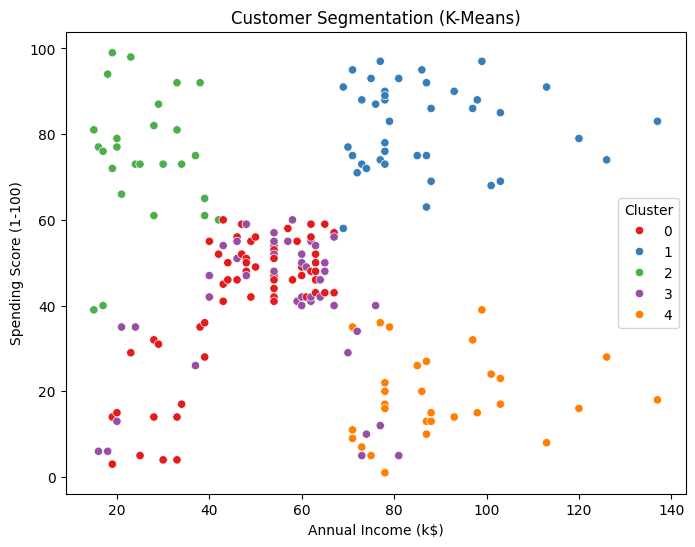

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1'
)
plt.title("Customer Segmentation (K-Means)")
plt.show()


In [ ]:
df.groupby('Cluster').mean()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.568966,55.275862,47.620690,41.706897
1,0.550000,32.875000,86.100000,81.525000
2,0.576923,25.769231,26.115385,74.846154
3,0.600000,26.733333,54.311111,40.911111
4,0.483871,44.387097,89.774194,18.483871


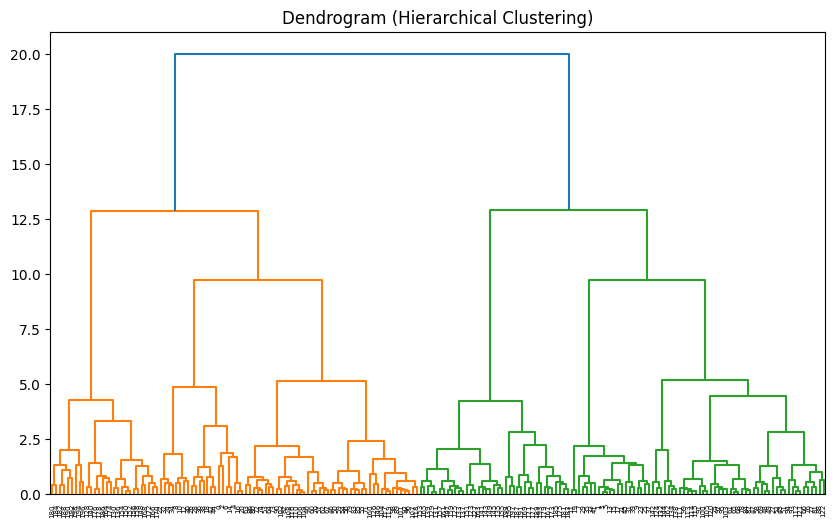

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrogram (Hierarchical Clustering)")
plt.show()


In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=5)
df['HC_Cluster'] = hc.fit_predict(X_scaled)
